In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/carrie1/ecommerce-data/data.csv


In [2]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/carrie1/ecommerce-data/data.csv",
    encoding="ISO-8859-1"
)

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/carrie1/ecommerce-data/data.csv",
    encoding="ISO-8859-1")
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
print("Nulls:\n", df.isnull().sum())


Nulls:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
df.dropna(subset=['CustomerID'], inplace=True)


In [7]:
print("Nulls:\n", df.isnull().sum())


Nulls:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [9]:
# 1. Check nulls
print("Nulls:\n", df.isnull().sum())

# 2. Drop rows with missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# 3. Remove cancelled orders (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Remove negative/zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 5. Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# 6. Convert InvoiceDate to datetime and extract useful fields
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

print("\nClean shape:", df.shape)
df.head()

Nulls:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Clean shape: (397884, 12)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,8,Wednesday


In [10]:
print("Total Revenue: £{:,.2f}".format(df['Revenue'].sum()))
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Customers:", df['CustomerID'].nunique())
print("Total Products:", df['Description'].nunique())
print("Countries:", df['Country'].nunique())

Total Revenue: £8,911,407.90
Total Orders: 18532
Total Customers: 4338
Total Products: 3877
Countries: 37


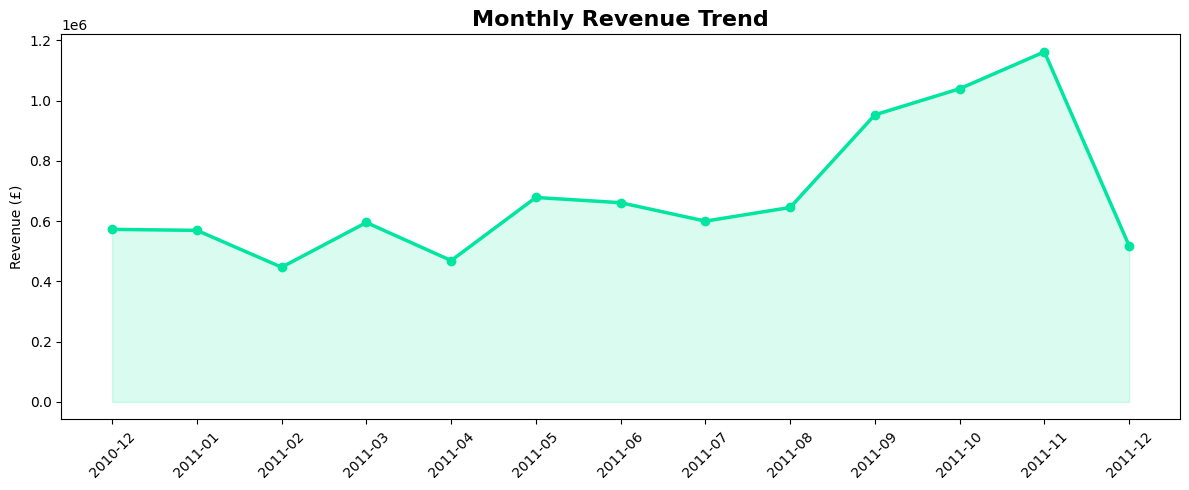

In [11]:
monthly = df.groupby('Month')['Revenue'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly['Month'], monthly['Revenue'], marker='o', color='#00e5a0', linewidth=2.5)
plt.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.15, color='#00e5a0')
plt.xticks(range(len(monthly)), monthly['Month'], rotation=45)
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

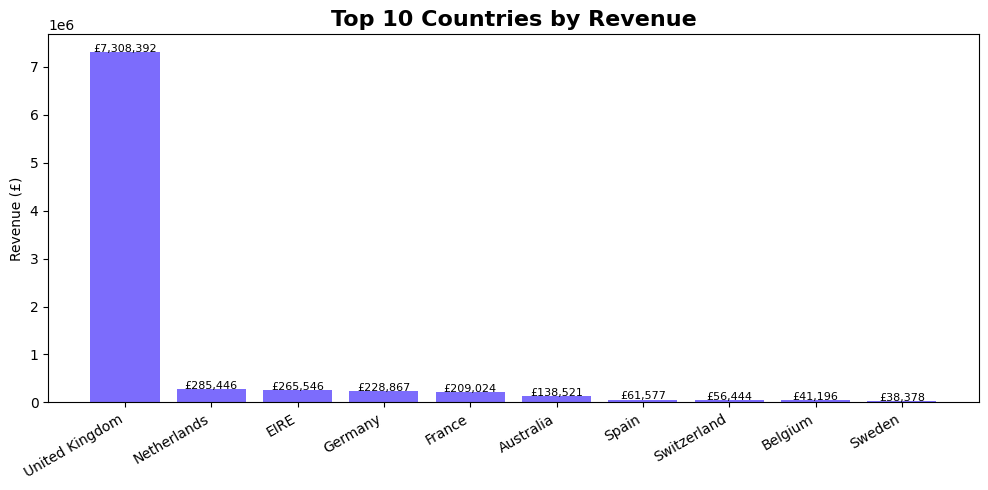

In [12]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
bars = plt.bar(country_rev.index, country_rev.values, color='#7c6cfc')
plt.title('Top 10 Countries by Revenue', fontsize=16, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Revenue (£)')
for bar, val in zip(bars, country_rev.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'£{val:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('country_revenue.png', dpi=150)
plt.show()

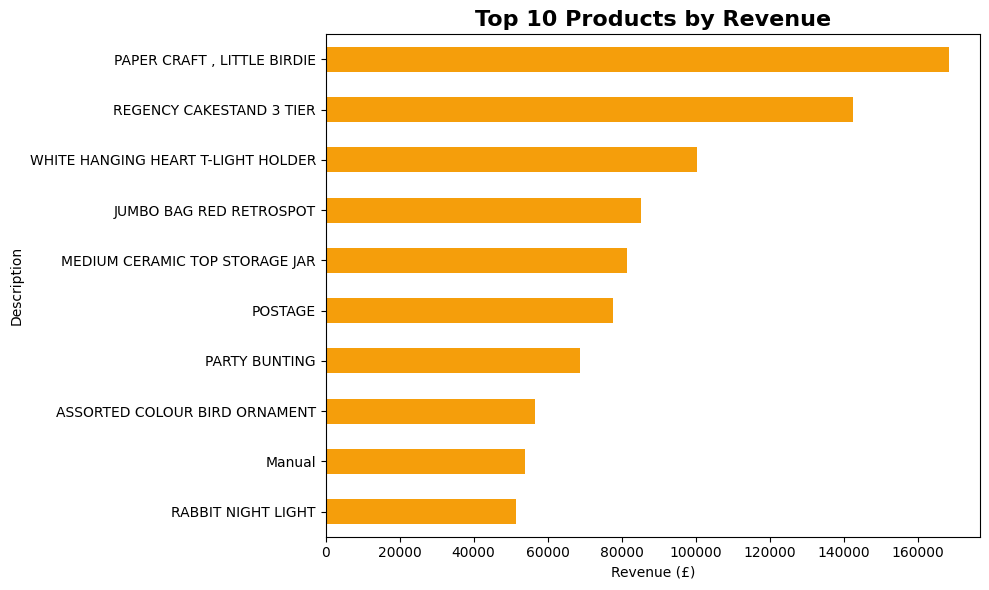

In [13]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh', color='#f59e0b')
plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()

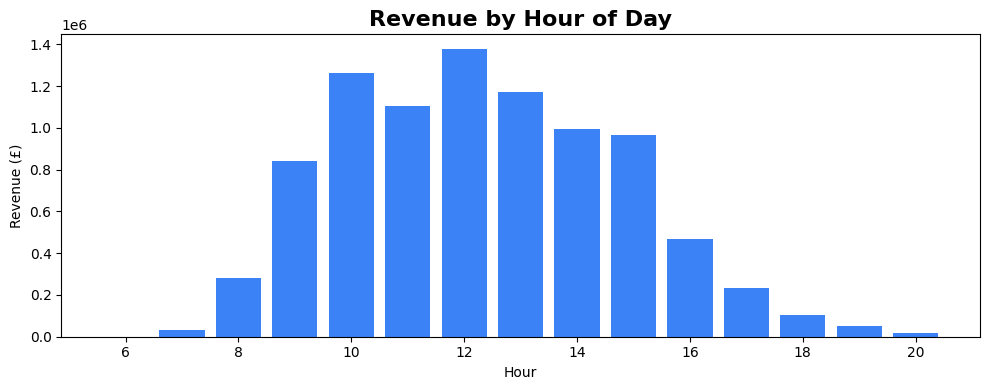

In [14]:
hourly = df.groupby('Hour')['Revenue'].sum()

plt.figure(figsize=(10, 4))
plt.bar(hourly.index, hourly.values, color='#3b82f6')
plt.title('Revenue by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('hourly_sales.png', dpi=150)
plt.show()

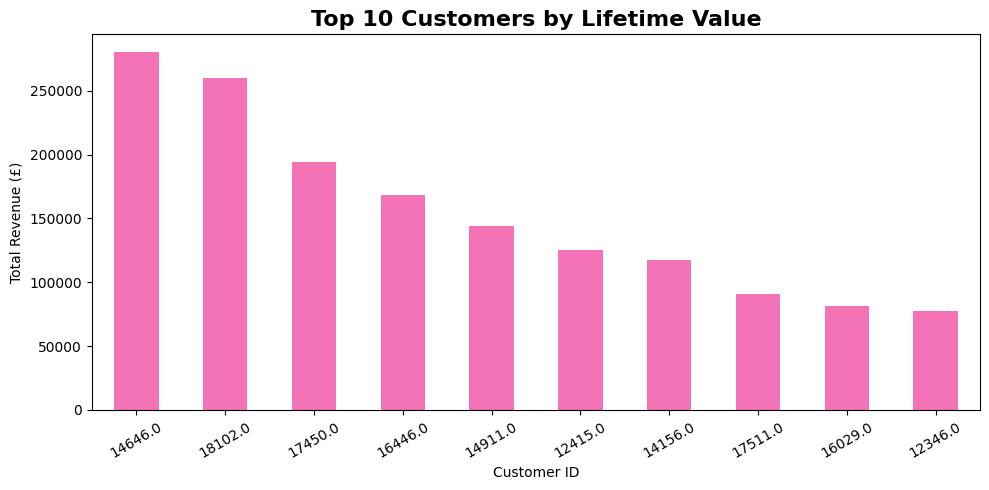

In [15]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_customers.plot(kind='bar', color='#f472b6')
plt.title('Top 10 Customers by Lifetime Value', fontsize=16, fontweight='bold')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('top_customers.png', dpi=150)
plt.show()

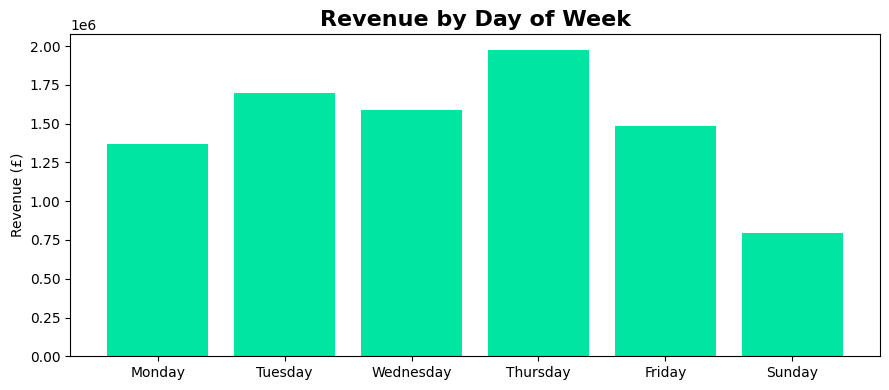

In [16]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
dow = df.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)

plt.figure(figsize=(9, 4))
plt.bar(dow.index, dow.values, color='#00e5a0')
plt.title('Revenue by Day of Week', fontsize=16, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('day_of_week.png', dpi=150)
plt.show()

In [17]:
import os
print(os.listdir())


['__notebook__.ipynb', 'top_customers.png', 'hourly_sales.png', 'monthly_revenue.png', 'country_revenue.png', 'top_products.png', 'day_of_week.png']


In [18]:
!pip install pandasql
from pandasql import sqldf
pysql = lambda q: sqldf(q, globals())

In [19]:
df['Month'] = df['Month'].astype(str)

In [20]:
pysql("SELECT * FROM df LIMIT 5;")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.000000,2.55,17850.0,United Kingdom,15.30,2010-12,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom,20.34,2010-12,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.000000,2.75,17850.0,United Kingdom,22.00,2010-12,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom,20.34,2010-12,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.000000,3.39,17850.0,United Kingdom,20.34,2010-12,8,Wednesday


In [21]:
q1 = """
SELECT
  ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue,
  COUNT(DISTINCT InvoiceNo) AS total_orders,
  COUNT(DISTINCT CustomerID) AS total_customers
FROM df
WHERE Quantity > 0 AND UnitPrice > 0;
"""
pysql(q1)

,total_revenue,total_orders,total_customers
0,8911407.9,18532,4338


In [22]:
q2 = """
SELECT
  Description,
  ROUND(SUM(Quantity * UnitPrice), 2) AS revenue,
  SUM(Quantity) AS units_sold
FROM df
WHERE Quantity > 0 AND UnitPrice > 0
GROUP BY Description
ORDER BY revenue DESC
LIMIT 10;
"""
pysql(q2)

,Description,revenue,units_sold
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
1,REGENCY CAKESTAND 3 TIER,142592.95,12402
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725
3,JUMBO BAG RED RETROSPOT,85220.78,46181
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
5,POSTAGE,77803.96,3120
6,PARTY BUNTING,68844.33,15291
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362
8,Manual,53779.93,7173
9,RABBIT NIGHT LIGHT,51346.20,27202


In [23]:
q3 = """
SELECT
  Country,
  ROUND(SUM(Quantity * UnitPrice), 2) AS revenue,
  COUNT(DISTINCT CustomerID) AS customers
FROM df
WHERE Quantity > 0 AND UnitPrice > 0
GROUP BY Country
ORDER BY revenue DESC
LIMIT 15;
"""
pysql(q3)

,Country,revenue,customers
0,United Kingdom,7308391.55,3920
1,Netherlands,285446.34,9
2,EIRE,265545.90,3
3,Germany,228867.14,94
4,France,209024.05,87
5,Australia,138521.31,9
6,Spain,61577.11,30
7,Switzerland,56443.95,21
8,Belgium,41196.34,25
9,Sweden,38378.33,8


In [24]:
q4 = """
SELECT
  SUBSTR(InvoiceDate, 1, 7) AS month,
  ROUND(SUM(Quantity * UnitPrice), 2) AS monthly_revenue,
  COUNT(DISTINCT InvoiceNo) AS orders
FROM df
WHERE Quantity > 0 AND UnitPrice > 0
GROUP BY month
ORDER BY month;
"""
pysql(q4)

,month,monthly_revenue,orders
0,2010-12,572713.89,1400
1,2011-01,569445.04,987
2,2011-02,447137.35,997
3,2011-03,595500.76,1321
4,2011-04,469200.36,1149
5,2011-05,678594.56,1555
6,2011-06,661213.69,1393
7,2011-07,600091.01,1331
8,2011-08,645343.90,1280
9,2011-09,952838.38,1755


In [25]:
q5 = """
SELECT
  CustomerID,
  COUNT(DISTINCT InvoiceNo) AS total_orders,
  ROUND(SUM(Quantity * UnitPrice), 2) AS lifetime_value
FROM df
WHERE Quantity > 0 AND UnitPrice > 0
  AND CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY lifetime_value DESC
LIMIT 10;
"""
pysql(q5)

,CustomerID,total_orders,lifetime_value
0,14646.0,73,280206.02
1,18102.0,60,259657.30
2,17450.0,46,194550.79
3,16446.0,2,168472.50
4,14911.0,201,143825.06
5,12415.0,21,124914.53
6,14156.0,55,117379.63
7,17511.0,31,91062.38
8,16029.0,63,81024.84
9,12346.0,1,77183.60


In [26]:
df_raw = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding='ISO-8859-1')

q6 = """
SELECT
  COUNT(CASE WHEN InvoiceNo LIKE 'C%' THEN 1 END) AS cancelled,
  COUNT(CASE WHEN InvoiceNo NOT LIKE 'C%' THEN 1 END) AS completed,
  ROUND(COUNT(CASE WHEN InvoiceNo LIKE 'C%' THEN 1 END) * 100.0 / COUNT(*), 2) AS cancel_rate_pct
FROM df_raw;
"""
pysql(q6)

,cancelled,completed,cancel_rate_pct
0,9288,532621,1.71


In [27]:
q7 = """
SELECT
  Country,
  ROUND(SUM(Quantity * UnitPrice) / COUNT(DISTINCT InvoiceNo), 2) AS avg_order_value
FROM df
WHERE Quantity > 0 AND UnitPrice > 0
GROUP BY Country
ORDER BY avg_order_value DESC
LIMIT 10;
"""
pysql(q7)

,Country,avg_order_value
0,Singapore,3039.90
1,Netherlands,3036.66
2,Australia,2430.20
3,Japan,1969.28
4,Lebanon,1693.88
5,Israel,1444.34
6,Brazil,1143.60
7,Switzerland,1106.74
8,Sweden,1066.06
9,Denmark,1053.07


In [28]:
q8 = """
SELECT * FROM (
  SELECT
    Country, Description,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue,
    RANK() OVER (PARTITION BY Country ORDER BY SUM(Quantity * UnitPrice) DESC) AS rnk
  FROM df
  WHERE Quantity > 0 AND UnitPrice > 0
  GROUP BY Country, Description
) ranked
WHERE rnk = 1
ORDER BY revenue DESC
LIMIT 10;
"""
pysql(q8)

,Country,Description,revenue,rnk
0,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1
1,Germany,POSTAGE,21001.00,1
2,France,POSTAGE,15454.00,1
3,Singapore,Manual,12158.90,1
4,Netherlands,RABBIT NIGHT LIGHT,9568.48,1
5,EIRE,REGENCY CAKESTAND 3 TIER,7388.55,1
6,Japan,RABBIT NIGHT LIGHT,6100.32,1
7,Spain,POSTAGE,5852.00,1
8,Belgium,POSTAGE,4269.00,1
9,Portugal,Manual,4223.94,1


In [29]:
q9 = """
WITH monthly AS (
  SELECT
    SUBSTR(InvoiceDate, 1, 7) AS month,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
  FROM df
  WHERE Quantity > 0 AND UnitPrice > 0
  GROUP BY month
)
SELECT
  month, revenue,
  LAG(revenue) OVER (ORDER BY month) AS prev_month,
  ROUND((revenue - LAG(revenue) OVER (ORDER BY month)) * 100.0
        / LAG(revenue) OVER (ORDER BY month), 2) AS growth_pct
FROM monthly;
"""
pysql(q9)

,month,revenue,prev_month,growth_pct
0,2010-12,572713.89,NaN,NaN
1,2011-01,569445.04,572713.89,-0.57
2,2011-02,447137.35,569445.04,-21.48
3,2011-03,595500.76,447137.35,33.18
4,2011-04,469200.36,595500.76,-21.21
5,2011-05,678594.56,469200.36,44.63
6,2011-06,661213.69,678594.56,-2.56
7,2011-07,600091.01,661213.69,-9.24
8,2011-08,645343.90,600091.01,7.54
9,2011-09,952838.38,645343.90,47.65


In [30]:
q10 = """
SELECT
  CustomerID,
  COUNT(DISTINCT SUBSTR(InvoiceDate, 1, 7)) AS active_months,
  ROUND(SUM(Quantity * UnitPrice), 2) AS total_spent
FROM df
WHERE Quantity > 0 AND UnitPrice > 0
  AND CustomerID IS NOT NULL
GROUP BY CustomerID
HAVING active_months >= 3
ORDER BY active_months DESC, total_spent DESC
LIMIT 10;
"""
pysql(q10)

,CustomerID,active_months,total_spent
0,14646.0,13,280206.02
1,14911.0,13,143825.06
2,17511.0,13,91062.38
3,13694.0,13,65039.62
4,15311.0,13,60767.90
5,13089.0,13,58825.83
6,17949.0,13,58510.48
7,15769.0,13,56252.72
8,15061.0,13,54534.14
9,14298.0,13,51527.30


In [31]:
df.to_csv('ecommerce_clean.csv', index=False)